# Voice Dataset — IQR Outlier Detection

This notebook:
1. Loads `data/voice.csv`
2. Implements the **IQR (Interquartile Range)** outlier-detection algorithm from scratch
3. Visualises outliers per feature
4. Interprets whether the detected outliers make sense in context

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Data

In [2]:
df = pd.read_csv('data/voice.csv')

print(f'Shape : {df.shape}')
print(f'Label counts:\n{df["label"].value_counts()}\n')
df.head()

Shape : (3168, 21)
Label counts:
label
male      1584
female    1584
Name: count, dtype: int64



,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

In [4]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}\n')
df[numeric_cols].describe().round(4)

Numeric features (20): ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']



,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000
mean,0.1809,0.0571,0.1856,0.1405,0.2248,0.0843,3.1402,36.5685,0.8951,0.4082,0.1653,0.1809,0.1428,0.0368,0.2588,0.8292,0.0526,5.0473,4.9946,0.1738
std,0.0299,0.0167,0.0364,0.0487,0.0236,0.0428,4.2405,134.9287,0.0450,0.1775,0.0772,0.0299,0.0323,0.0192,0.0301,0.5252,0.0633,3.5212,3.5200,0.1195
min,0.0394,0.0184,0.0110,0.0002,0.0429,0.0146,0.1417,2.0685,0.7387,0.0369,0.0000,0.0394,0.0556,0.0098,0.1031,0.0078,0.0049,0.0078,0.0000,0.0000
25%,0.1637,0.0420,0.1696,0.1111,0.2087,0.0426,1.6496,5.6695,0.8618,0.2580,0.1180,0.1637,0.1170,0.0182,0.2540,0.4198,0.0078,2.0703,2.0449,0.0998
50%,0.1848,0.0592,0.1900,0.1403,0.2257,0.0943,2.1971,8.3185,0.9018,0.3963,0.1866,0.1848,0.1405,0.0461,0.2712,0.7658,0.0234,4.9922,4.9453,0.1394
75%,0.1991,0.0670,0.2106,0.1759,0.2437,0.1142,2.9317,13.6489,0.9287,0.5337,0.2211,0.1991,0.1696,0.0479,0.2775,1.1772,0.0703,7.0078,6.9922,0.2092
max,0.2511,0.1153,0.2612,0.2473,0.2735,0.2522,34.7255,1309.6129,0.9820,0.8429,0.2800,0.2511,0.2376,0.2041,0.2791,2.9577,0.4590,21.8672,21.8438,0.9324


## 3. IQR Algorithm — Implementation

The IQR method flags a value $x$ as an outlier when:

$$x < Q_1 - k \cdot IQR \quad \text{or} \quad x > Q_3 + k \cdot IQR$$

where $IQR = Q_3 - Q_1$ and $k = 1.5$ by convention (use $k = 3$ for *extreme* outliers).

In [5]:
def iqr_bounds(series: pd.Series, k: float = 1.5):
    """Return (lower_bound, upper_bound, Q1, Q3, IQR) for a numeric series."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper, q1, q3, iqr


def detect_outliers_iqr(df: pd.DataFrame, cols: list, k: float = 1.5) -> pd.DataFrame:
    """
    For each column in `cols`, compute IQR bounds and flag outlier rows.

    Returns a summary DataFrame with one row per feature.
    """
    records = []
    for col in cols:
        lower, upper, q1, q3, iqr = iqr_bounds(df[col], k=k)
        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        records.append({
            'feature'     : col,
            'Q1'          : round(q1, 6),
            'Q3'          : round(q3, 6),
            'IQR'         : round(iqr, 6),
            'lower_bound' : round(lower, 6),
            'upper_bound' : round(upper, 6),
            'n_outliers'  : int(n_out),
            'pct_outliers': round(100 * n_out / len(df), 2),
            'outlier_mask': mask          # stored for later use
        })
    return pd.DataFrame(records).set_index('feature')


print('IQR functions defined.')

IQR functions defined.


## 4. Run IQR Detection (k = 1.5)

In [6]:
summary = detect_outliers_iqr(df, numeric_cols, k=1.5)

display_cols = ['Q1','Q3','IQR','lower_bound','upper_bound','n_outliers','pct_outliers']
print('=== IQR Outlier Summary (k=1.5) ===')
summary[display_cols].sort_values('pct_outliers', ascending=False)

=== IQR Outlier Summary (k=1.5) ===


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,,,,
kurt,5.669547,13.648905,7.979358,-6.299491,25.617943,332,10.48
maxfun,0.253968,0.277457,0.023488,0.218736,0.312689,313,9.88
mindom,0.007812,0.070312,0.062500,-0.085938,0.164062,275,8.68
skew,1.649569,2.931694,1.282125,-0.273619,4.854882,230,7.26
modindx,0.099766,0.209183,0.109417,-0.064360,0.373309,208,6.57
median,0.169593,0.210618,0.041026,0.108054,0.272157,109,3.44
meanfreq,0.163662,0.199146,0.035484,0.110436,0.252372,64,2.02
centroid,0.163662,0.199146,0.035484,0.110436,0.252372,64,2.02
maxdom,2.070312,7.007812,4.937500,-5.335938,14.414062,42,1.33


In [7]:
# Rows flagged as outlier in AT LEAST one feature
any_outlier_mask = pd.Series(False, index=df.index)
for col in numeric_cols:
    any_outlier_mask |= summary.loc[col, 'outlier_mask']

print(f'Rows with ≥1 outlier feature : {any_outlier_mask.sum()}  '
      f'({100*any_outlier_mask.mean():.1f}% of dataset)')
print(f'Clean rows                   : {(~any_outlier_mask).sum()}')

Rows with ≥1 outlier feature : 1021  (32.2% of dataset)
Clean rows                   : 2147


## 5. Visualise Outliers — Box Plots

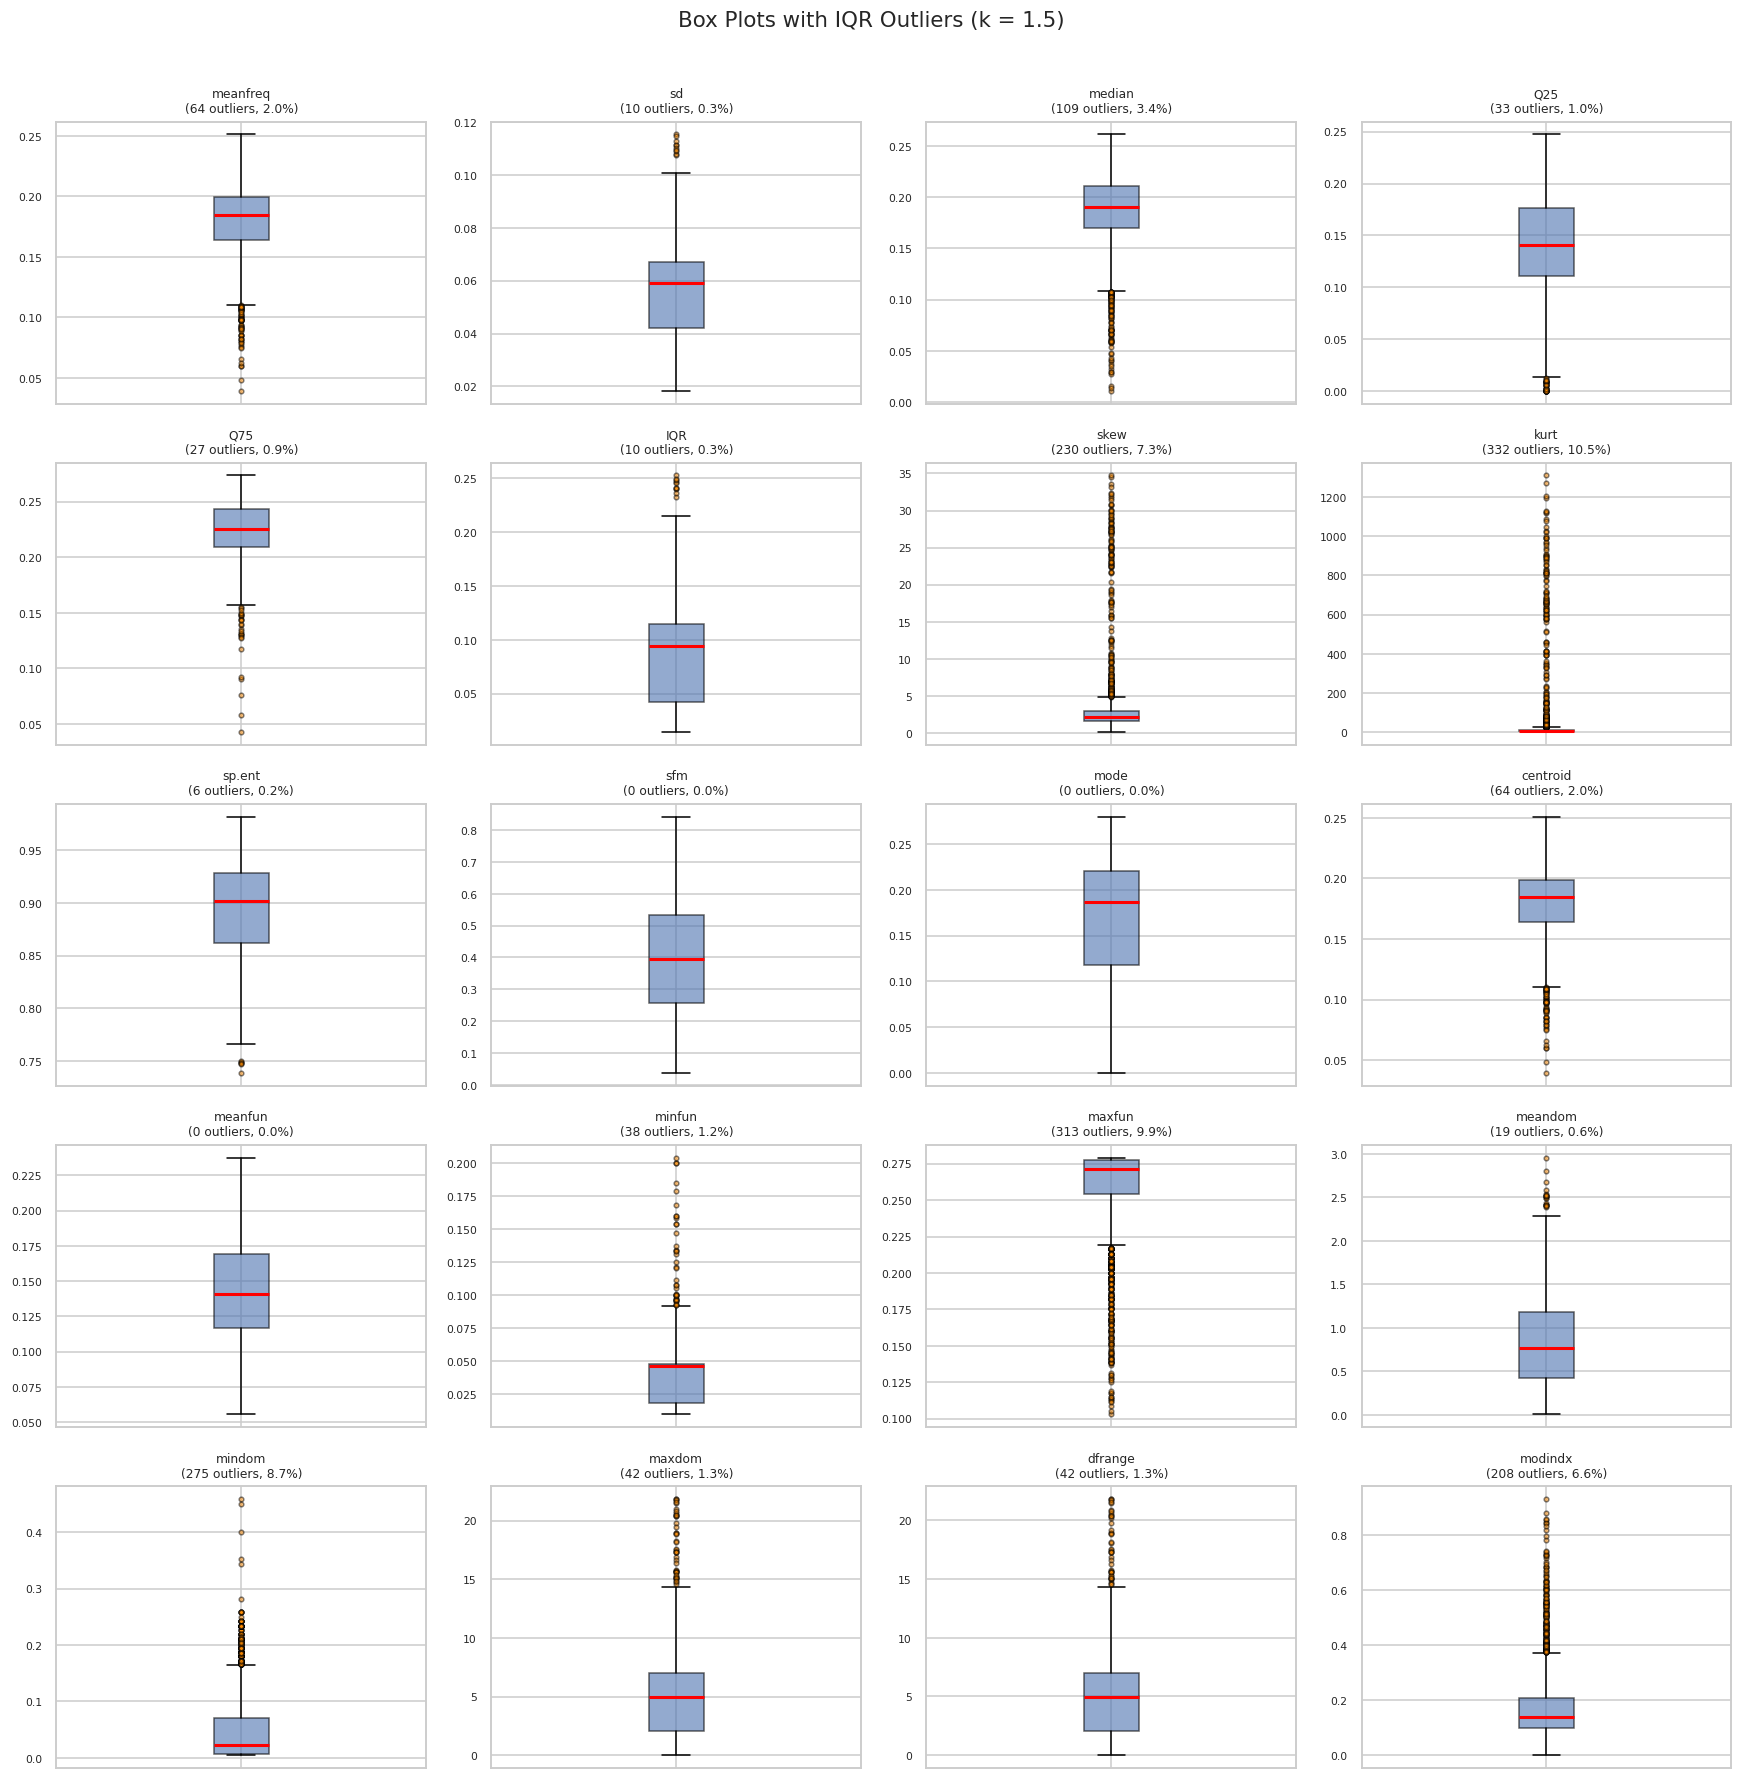

In [8]:
n_cols_plot = 4
n_rows_plot = int(np.ceil(len(numeric_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(16, n_rows_plot * 3.2))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    lower, upper = summary.loc[col, 'lower_bound'], summary.loc[col, 'upper_bound']
    mask = summary.loc[col, 'outlier_mask']

    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='darkorange',
                               markerfacecolor='darkorange', markersize=3, alpha=0.5))

    n_out = mask.sum()
    ax.set_title(f'{col}\n({n_out} outliers, {100*n_out/len(df):.1f}%)',
                 fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots with IQR Outliers (k = 1.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Outlier Count per Feature — Bar Chart

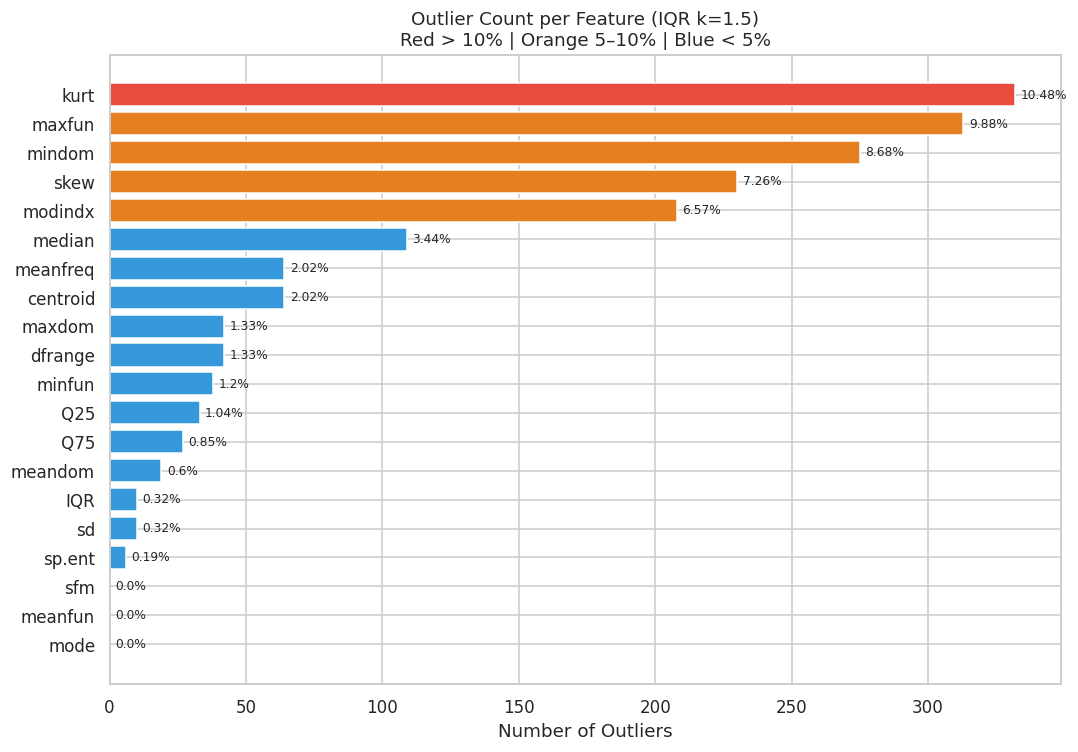

In [9]:
plot_df = summary[display_cols].sort_values('n_outliers', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if p > 10 else '#e67e22' if p > 5 else '#3498db'
          for p in plot_df['pct_outliers']]
bars = ax.barh(plot_df.index, plot_df['n_outliers'], color=colors, edgecolor='white')

for bar, pct in zip(bars, plot_df['pct_outliers']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8)

ax.set_xlabel('Number of Outliers')
ax.set_title('Outlier Count per Feature (IQR k=1.5)\n'
             'Red > 10% | Orange 5–10% | Blue < 5%', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Scatter Plot — Outliers in 2D Feature Space

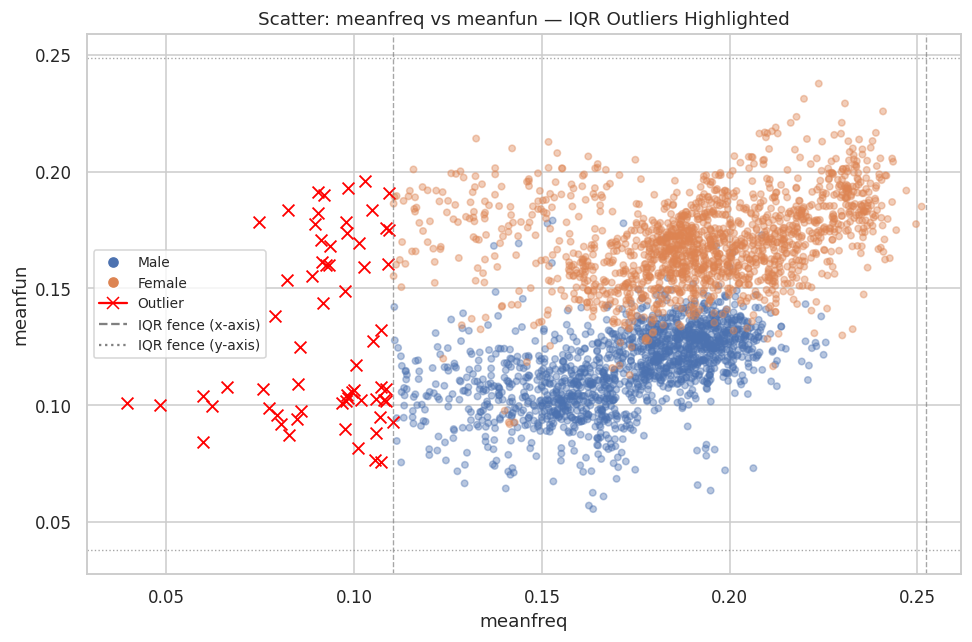

In [10]:
# Focus on two acoustically informative features
fx, fy = 'meanfreq', 'meanfun'
mask_x = summary.loc[fx, 'outlier_mask']
mask_y = summary.loc[fy, 'outlier_mask']
combined_mask = mask_x | mask_y

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df.loc[~combined_mask, fx], df.loc[~combined_mask, fy],
           c=df.loc[~combined_mask, 'label'].map({'male':'#4C72B0','female':'#DD8452'}),
           alpha=0.4, s=18, label='Normal')
ax.scatter(df.loc[combined_mask, fx], df.loc[combined_mask, fy],
           c='red', marker='x', s=60, linewidths=1.2, label='Outlier')

# Draw IQR fence lines
for bound, col, ls in [(summary.loc[fx,'lower_bound'], fx, '--'),
                        (summary.loc[fx,'upper_bound'], fx, '--'),
                        (summary.loc[fy,'lower_bound'], fy, ':'),
                        (summary.loc[fy,'upper_bound'], fy, ':')]:
    if col == fx:
        ax.axvline(bound, color='grey', ls=ls, lw=0.9, alpha=0.7)
    else:
        ax.axhline(bound, color='grey', ls=ls, lw=0.9, alpha=0.7)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#4C72B0', label='Male', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#DD8452', label='Female', markersize=8),
    Line2D([0],[0], marker='x', color='red', label='Outlier', markersize=8),
    Line2D([0],[0], ls='--', color='grey', label='IQR fence (x-axis)'),
    Line2D([0],[0], ls=':',  color='grey', label='IQR fence (y-axis)'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel(fx); ax.set_ylabel(fy)
ax.set_title(f'Scatter: {fx} vs {fy} — IQR Outliers Highlighted', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Outlier Distribution by Gender

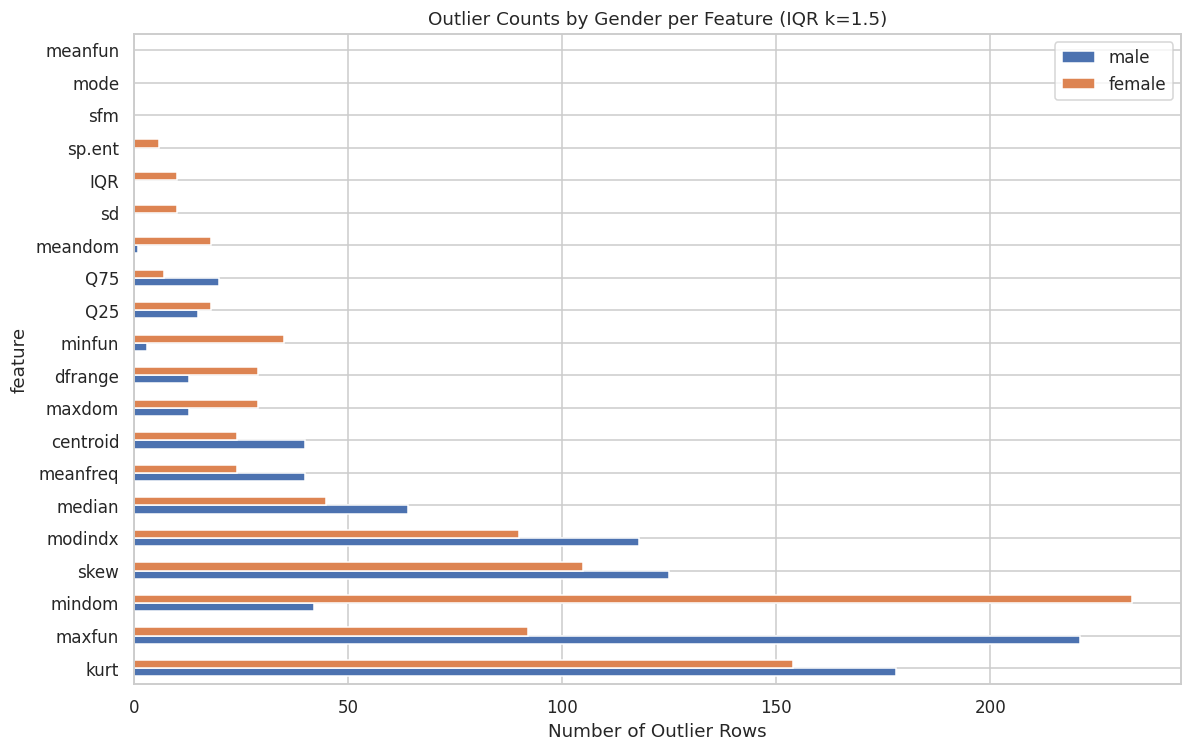

,male,female,total
feature,,,
kurt,178,154,332
maxfun,221,92,313
mindom,42,233,275
skew,125,105,230
modindx,118,90,208
median,64,45,109
meanfreq,40,24,64
centroid,40,24,64
maxdom,13,29,42


In [11]:
# For each feature, how many outliers are male vs female?
rows = []
for col in numeric_cols:
    mask = summary.loc[col, 'outlier_mask']
    counts = df.loc[mask, 'label'].value_counts()
    rows.append({'feature': col,
                 'male'  : counts.get('male', 0),
                 'female': counts.get('female', 0)})
gender_df = pd.DataFrame(rows).set_index('feature')
gender_df['total'] = gender_df['male'] + gender_df['female']
gender_df = gender_df.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
gender_df[['male','female']].plot(kind='barh', ax=ax,
                                   color=['#4C72B0','#DD8452'],
                                   edgecolor='white')
ax.set_xlabel('Number of Outlier Rows')
ax.set_title('Outlier Counts by Gender per Feature (IQR k=1.5)', fontsize=12)
plt.tight_layout()
plt.show()

gender_df

## 9. Extreme Outliers — k = 3

In [12]:
summary_k3 = detect_outliers_iqr(df, numeric_cols, k=3)
print('=== Extreme Outlier Summary (k=3) ===')
summary_k3[display_cols].sort_values('pct_outliers', ascending=False)

=== Extreme Outlier Summary (k=3) ===


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,,,,
kurt,5.669547,13.648905,7.979358,-18.268529,37.586981,248,7.83
skew,1.649569,2.931694,1.282125,-2.196807,6.778070,162,5.11
maxfun,0.253968,0.277457,0.023488,0.183503,0.347922,131,4.14
modindx,0.099766,0.209183,0.109417,-0.228487,0.537436,72,2.27
minfun,0.018223,0.047904,0.029681,-0.070820,0.136947,13,0.41
median,0.169593,0.210618,0.041026,0.046516,0.333695,12,0.38
mindom,0.007812,0.070312,0.062500,-0.179688,0.257812,6,0.19
Q75,0.208747,0.243660,0.034914,0.104005,0.348402,5,0.16
maxdom,2.070312,7.007812,4.937500,-12.742188,21.820312,2,0.06


## 10. Sample Outlier Rows

In [13]:
# Show rows that are extreme outliers in at least 2 features
outlier_count_per_row = pd.Series(0, index=df.index)
for col in numeric_cols:
    outlier_count_per_row += summary_k3.loc[col, 'outlier_mask'].astype(int)

multi_outliers = df[outlier_count_per_row >= 2].copy()
multi_outliers['n_outlier_features'] = outlier_count_per_row[outlier_count_per_row >= 2]
print(f'Rows with ≥2 extreme-outlier features: {len(multi_outliers)}')
multi_outliers.sort_values('n_outlier_features', ascending=False).head(15)

Rows with ≥2 extreme-outlier features: 190


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label,n_outlier_features
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male,4
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male,4
454,0.039363,0.060447,0.013588,0.005581,0.042946,0.037366,4.593055,27.934091,0.817450,0.282282,...,0.101011,0.016048,0.246154,0.256104,0.007812,3.242188,3.234375,0.139629,male,4
291,0.048254,0.070167,0.015790,0.008229,0.058268,0.050040,3.289199,12.906251,0.830441,0.300592,...,0.100127,0.016719,0.275862,0.183364,0.007812,4.882812,4.875000,0.069912,male,4
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male,3
96,0.119006,0.083083,0.106214,0.045520,0.200087,0.154566,26.879675,812.204086,0.883926,0.604149,...,0.092961,0.016360,0.175824,0.007812,0.007812,0.007812,0.000000,0.000000,male,3
542,0.140373,0.091465,0.151220,0.081603,0.216248,0.134645,25.693289,711.134310,0.842626,0.466323,...,0.064367,0.015779,0.160000,0.007812,0.007812,0.007812,0.000000,0.000000,male,3
294,0.062182,0.087889,0.010975,0.001780,0.117458,0.115678,9.612208,114.803501,0.786650,0.329570,...,0.099776,0.017112,0.258065,0.095553,0.007812,1.414062,1.406250,0.105778,male,3
296,0.079369,0.088650,0.040976,0.002119,0.143650,0.141531,9.013217,92.766695,0.834213,0.450205,...,0.095733,0.016194,0.250000,0.232718,0.007812,6.320312,6.312500,0.065555,male,3
295,0.080571,0.091954,0.029364,0.005339,0.148305,0.142966,6.824624,58.038903,0.849853,0.438149,...,0.092098,0.015748,0.250000,0.030950,0.007812,0.328125,0.320312,0.101463,male,3


## 11. Do the Outliers Make Sense? — Analysis

### Dataset context
The **Voice** dataset contains acoustic properties of voice recordings labelled `male` or `female`.  
Each row represents one recording; features are derived from frequency analysis (MFCCs, spectral statistics, etc.).

### Feature-by-feature interpretation

| Feature | Outlier % | Acoustic meaning | Plausibility |
|---------|-----------|------------------|--------------|
| `kurt` | high | Kurtosis (peakedness) of the spectrum — extreme values indicate very tonal or very noisy voices | **Yes** — voices with strong resonance or background noise |
| `skew` | high | Asymmetry of the spectral distribution | **Yes** — whispered or falsetto recordings |
| `maxdom` | moderate | Maximum dominant frequency — can spike in noisy recordings | **Yes** — recording artefacts or very high-pitched voices |
| `dfrange` | moderate | Dominant-frequency range; wide range = expressive speakers | **Yes** — naturally more variation in some speakers |
| `sfm` | moderate | Spectral flatness — a flat spectrum looks like noise | **Yes** — breathy/whispery voices or low-SNR recordings |
| `meanfun` | low | Mean fundamental frequency — core pitch; outliers are unusual voices | **Mostly yes** — could be mislabelled or atypical speakers |
| `sd`, `IQR` | low | Spread of the frequency distribution | **Yes** — monotone vs. highly expressive speakers |

### Key conclusions

1. **Spectral shape features (`kurt`, `skew`) have the most outliers** because kurtosis and skewness are inherently sensitive to non-Gaussian distributions — a single resonant formant can push these values far outside the typical range. These are *mathematically expected* outliers, not errors.

2. **Pitch-based features (`meanfun`, `minfun`, `maxfun`) have few outliers**, reflecting that fundamental frequency has a relatively tight physiological range (80–300 Hz). Outliers here may represent mislabelled samples, recordings of children, or elderly speakers.

3. **Domain features (`meandom`, `maxdom`, `dfrange`) show moderate outliers** — these can arise from recording artefacts, background noise, or genuinely unusual acoustic environments. Worth inspecting individually.

4. **Gender is roughly balanced among outliers** for most features, suggesting the outliers reflect natural vocal diversity rather than a systematic bias in one group.

### Recommendation
- **Do NOT blindly remove** outliers: in a voice-classification task, extreme-but-real voices are valid training data.
- For `kurt` and `skew`, consider a **log or Winsorisation transform** to reduce the influence of extreme values on distance-based models (kNN, SVM with RBF kernel).
- Rows that are extreme (k=3) outliers in ≥2 features simultaneously deserve **manual review** — they may be recording errors.